# Plane-parallel slab example showing the usage of:
# High-level `LineRt` with callable fields

This notebook mirrors `docs/examples/plane_parallel_hl.py`
but in interactive form.  A uniform slab of CO (J=1->0) at
T = 2.7 K is illuminated from one face; photons scatter in
the line and are continuously absorbed by dust.  The field
arrays (`n_species`, `temperature`, `vel`) are provided as
**callables** so they can be spatially varying.

Run directory is auto-created under `/dev/shm/line_rt/`.


In [24]:
############################################################
# Import things
##############################
# For debugging purposes
%load_ext autoreload
%autoreload 2
##############################
# Load the pipeline without installation (works with
# symlinks too).  If installed (``pip install -e .``),
# replace the import block below with:
# from line_rt import LineRt, TransitionInfo, AU, Lsun
##############################
import importlib.util, os;
def _find_pipeline( anchor = 'line_rt.py', start = None ):
    # Jupyter has no __file__; walk up from the notebook's
    # working directory to locate the repo root (same idea
    # as __file__-based resolution in plain scripts).
    import os;
    d = os.path.abspath( start or os.getcwd(  ) );
    for i in range( 4 ):        # At most 4 trials
        cand = os.path.join( d, anchor );
        if os.path.isfile( cand ):
            return cand;
        parent = os.path.dirname( d );
        if parent == d:
            raise FileNotFoundError\
            ( "line_rt.py not found above %r" %
              os.getcwd(  ) );
        d = parent;
    #
#
pipeline_file = _find_pipeline(  );
module_spec   = importlib.util.spec_from_file_location\
              ( 'line_rt', pipeline_file );
line_rt = importlib.util.module_from_spec( module_spec );
module_spec.loader.exec_module( line_rt );
LineRt          = line_rt.LineRt;
TransitionInfo  = line_rt.TransitionInfo;
AU              = line_rt.AU;
Lsun            = line_rt.Lsun;
##############################

%matplotlib inline
import matplotlib;
import matplotlib.pyplot as plt;
from numpy import full, zeros, linspace, asarray, sqrt;

#  Kratos binary location - MUST be set explicitly (no
#  default).  Either pass kratos_root=... to LineRt, or set
#  the env var: %env KRATOS_ROOT /path/to/kratos_build_tree
KRATOS_ROOT = os.path.expanduser( '~/apps/kratos_line_rt' );
############################################################


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
############################################################
# 2.1 Configure the species and transition properties
##############################

# CO J=1->0 (idx 0)
ti = TransitionInfo( 'CO', 0 );

# Show the transition information
ti.show_transition(  );
# Use the following line for all species available:
# ti.show_transitions(  );

##############################
# 2.2 Define the fields
##############################

temperature = 2.7;  # Kelvin

tau0_slab = 1e1;
sigma_co  = ti.cross_section( temperature );
L_slab_cm = 10.0 * AU;   # x_min=-5, x_max=5 -> L=10 AU
n_species = ( tau0_slab / L_slab_cm ) / sigma_co; # cm^-3

# Or you can write n_species in cm^-3 on your own, no need
# to compute from the things above, like this:
# n_species = 1e2

def n_total_callable( X, Y, Z ):
    res = full( X.shape, n_species );
    res[ X > 0 ] *= 2;
    return res;

def temperature_callable( X, Y, Z ):
    return full( X.shape, temperature );

def vx_callable( X, Y, Z ):
    return zeros( X.shape );
#
############################################################


Species     : CO
Transition  : idx=0  1 -> 0
  A_ul      : 7.200e-08 s^-1
  freq      : 115.2710 GHz
  lambda    : 2600.7622 um
  E_u/K     : 3.85 K
  mol_mass  : 28.0 amu (built-in table)


Mesh: (64, 16, 2), external photon sources: 1
=== Sources (1) ===
  [0] slab, 20000 packets, flux = 1000000.0 photons cm⁻² s⁻¹
      x=-5, dir=+x, y=full, z=full, vel_offset=0.000e+00 cm/s, sigma=2.821e+03 cm/s


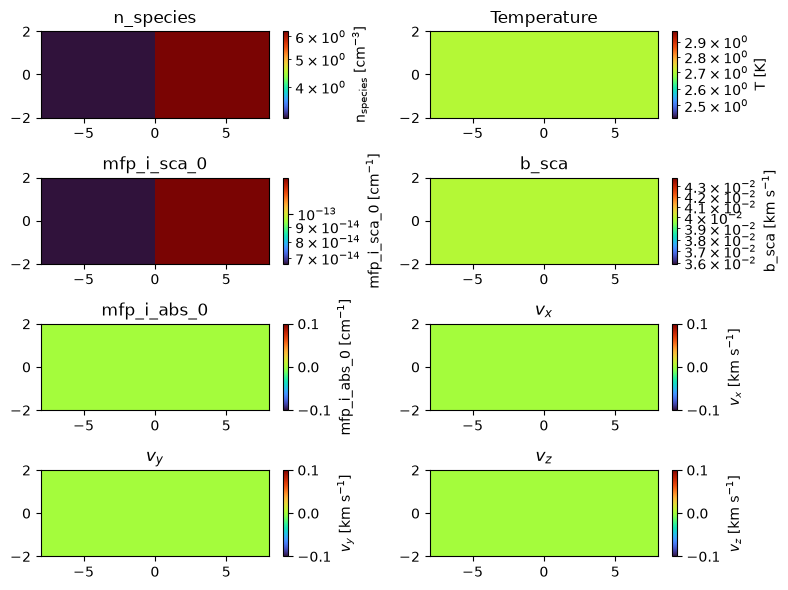

In [4]:
############################################################
# 3.0 Configure the LineRT object
##############################
# Pass the callables directly as n_species, temperature,
# and vel.  LineRt calls them internally after building
# the mesh.

rt = LineRt(
    n_cell       = ( 64, 16,  2 ),
    x_min        = ( -8, -2,  0 ),
    x_max        = (  8,  2, 0.2 ),
    unit_l0      = AU, unit_t0 = 1.0,

    transition_info = ti,
    n_species    = n_total_callable,
    temperature  = temperature_callable,
    vel          = ( vx_callable, 0.0, 0.0 ),

    ph_mode      = 2, # R_IIA const-mem (production)
    n_step       = 20000, n_scat = 10000,
    visualize    = False,
    kratos_root  = KRATOS_ROOT,
);
rt.set_boundary( 'fre fre per per per per' );

# Plot the configured input fields (no Kratos run) to verify:
# n_species, temperature, mfp_i_sca_0, b_sca, mfp_i_abs_0, vx
rt.plot_input( figsize = ( 8, 6 ) );

############################################################
#  3.1 Source (photon-number flux, default units)
#
#  Lowlevel: F0 = 1e6 photon/cm^2/s, sv = b_sca/sqrt(2),
#  x=-4.999. With default units='photon', flux is photon
#  number [photons cm^-2 s^-1] - no energy conversion
#  needed.  Pass units='energy' for erg cm^-2 s^-1 (uses the
#  transition wavelength automatically).

F0_cgs = 1e6;   # photon number flux [photons cm^-2 s^-1]

rt.add_source( type     = 'slab', x = -5, direction = '+x',
  n_photon = 20000,
  flux     = F0_cgs,   # photon-number flux [photons cm^-2 s^-1]
  sigma    = ti.doppler_b( temperature ) / sqrt( 2 ) );


print( 'Mesh: %s, external photon sources: %d' \
       % ( rt._n_cell, len( rt._sources ) ) );
rt.show_sources(  );


############################################################


In [ ]:
############################################################
#  4. Run the iterations!
##############################
# The run directory is printed and everything (.par, .bin
# files) goes under /dev/shm/line_rt/rt_<timestamp>/

n_cycle = 3;
print( 'Running %d MC cycles ...' % n_cycle );
rt.run( n_cycle );

print( '\n============================================\n' );

res_list = rt._results[ 'results' ];
mesh     = rt._results[ 'mesh' ];
nxc      = int( mesh[ 'n_cell' ][ 0 ] );
x_cell   = linspace( -8, 8, nxc );

for k, res in enumerate( res_list ):
    flx   = res.get( 'flx' );
    exc   = res.get( 'exc_flux_flat',
                     res.get( 'excitation_flux' ) );
    n_esc = len( res.get( 'photons', {} ).get( 'vel', [] ) );
    if flx is not None:
        print( 'Cycle %d: flx_max=%.2e, n_esc=%d' \
               % ( k, flx.max(  ), n_esc ) );
    else:
        print( '  Cycle %d: flx=N/A, n_esc=%d'
               % ( k, n_esc ) );
############################################################


Running 3 MC cycles ...
=== Consistency check ===
  species  : CO (10 levels, 9 transitions)
  n_species: <callable n_total_callable> cm⁻³
  temperature: <function temperature_callable at 0x78cd6043b7f0> K
  Transition #0: J=1->0, E_u=3.8 K, E_l=0.0 K, g_u=3, g_l=1, A_ul=7.20e-08 s⁻¹, ν=115.271 GHz, λ=2600.8 µm
  σ₀ = (b_sca to be resolved from callable at runtime)
  b_sca    : (not provided)
  mfp_i_sca_0: (not provided)
  ── Using Group 1 (species-based) ──
  sources  : 1 source(s)
    [0] slab, 20000 photons, 1000000.0 photons cm⁻² s⁻¹
=== All checks passed ===

[LineRt] Run directory: /dev/shm/line_rt/rt_20260802_193002
[iterate] Run directory: /dev/shm/line_rt/rt_20260802_193002
Wrote fields (fixed): /dev/shm/line_rt/rt_20260802_193002/fields_fixed.bin
Wrote fields (line): /dev/shm/line_rt/rt_20260802_193002/fields_cycle0.bin
Wrote photons: /dev/shm/line_rt/rt_20260802_193002/photons_cycle0.bin (20000 photons, 9 cols)
Wrote par file: /dev/shm/line_rt/rt_20260802_193002/cycle0.par


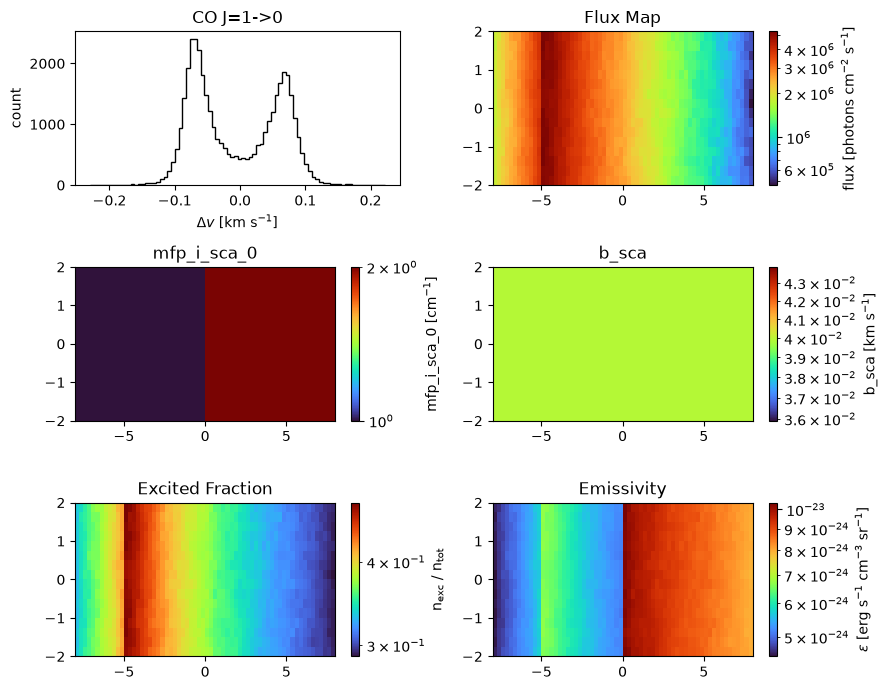

In [14]:
############################################################
#  5. Plot (default multi-panel)
##############################
# `line_rt.default_plot` (re-exported from `core.visualize`)
# generates a 2-column, N-row panel grid.  The default field
# list: emergent spectrum (km/s histogram), flux map,
# mfp_i_sca_0, b_sca, excited fraction, emissivity - all as
# logarithmic colormaps (except the spectrum).  Missing
# fields leave a blank panel with title.  Pass `dyn_range=True`
# to clip the color scale to integer-dex bounds.
##############################

fig, axes = rt.plot_results( figsize = ( 9, 7 ) );
############################################################


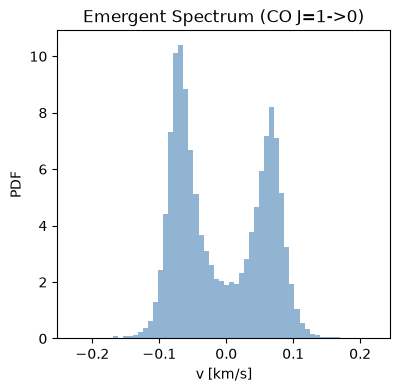

In [15]:
############################################################
# Emergent spectra
##############################

spectrum = rt._results.get( 'spectrum', {} );
vel_data = asarray( spectrum.get( 'vel', [ ] ) );

fig, ax = plt.subplots( figsize = ( 4.3, 4 ) );
if len( vel_data ) > 0:
    ax.hist( vel_data * 1e-5, bins = 60, density = True, \
             alpha = 0.6, color = 'steelblue' );
    ax.set( xlabel = 'v [km/s]', ylabel = 'PDF' );
else:
    ax.text( 0.5, 0.5, 'No escaped photons', \
             transform = ax.transAxes, ha = 'center' );
ax.set_title( 'Emergent Spectrum (CO J=1->0)' );
plt.show(  );
############################################################

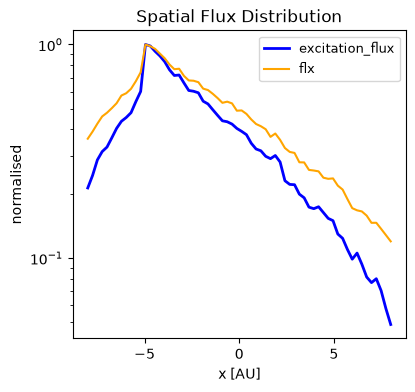

In [16]:
############################################################
# Spatial distribution
##############################

exc_flat = rt._results.get( 'exc_flux_flat' );
flx_flat = rt._results.get( 'flx' );

fig, ax = plt.subplots( figsize = ( 4.3, 4 ) );
if exc_flat is not None and flx_flat is not None:
    # 3D arrays (nz, ny, nx) -> take the x-profile at z=y=0
    exc_x = exc_flat[ 0, 0, : ];
    flx_x = flx_flat[ 0, 0, : ];
    ax.plot( x_cell, exc_x / ( exc_x.max(  ) or 1 ), 'b-',
             lw = 2, label = 'excitation_flux' );
    ax.plot( x_cell, flx_x / ( flx_x.max(  ) or 1 ),
             color = 'orange',  lw = 1.5, label = 'flx' );
    ax.set( xlabel = 'x [AU]', ylabel = 'normalised' );
    ax.set_yscale( 'log' );
    ax.legend( fontsize = 9 );
else:
    ax.text( 0.5, 0.5, 'No flux data',
             transform = ax.transAxes, ha = 'center' );
ax.set_title( 'Spatial Flux Distribution' );
plt.show(  );
############################################################

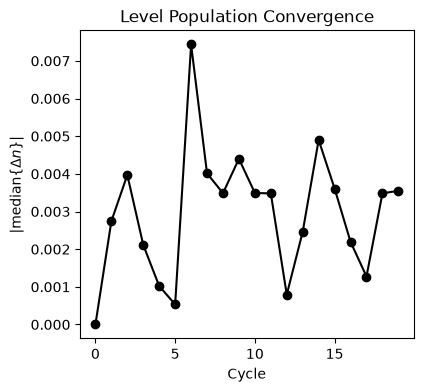

In [22]:
############################################################
# Population convergence; not very meaningful as the
# Monte-Carlo methods are always quite noisy
##############################

pop_hist = [ r[ 'populations' ] for r in res_list \
             if 'populations' in r ];

fig, ax = plt.subplots( figsize = ( 4.3, 4 ) );
if len( pop_hist ) >= 2:
    from core.visualize import plot_convergence;
    plot_convergence( ax, pop_hist,
                      list( range( len( pop_hist ) ) ) );
else:
    ax.text( 0.5, 0.5, 'No convergence data', \
             transform = ax.transAxes, ha = 'center' );
ax.set_title( 'Level Population Convergence' );
plt.show(  );
############################################################

In [ ]:
############################################################
# Run directory structure
##############################

run_dir = rt._results.get( 'run_dir' ) or rt._resolve_path(  );
print( 'Run directory: %s' % run_dir );
for f in sorted( os.listdir( run_dir ) ):
    sz = os.path.getsize( os.path.join( run_dir, f ) );
    print( '  %-30s  %10d bytes' % ( f, sz ) );
############################################################